# Food Security Risk Analysis — Marsabit County, Kenya

**Module:** `arin_climate.food_security`  
**Study area:** Marsabit County, Kenya — northern arid/semi-arid zone  
**Analysis period:** 2018–2023 · Baseline climatology: 2001–2017  
**Goal:** Map food insecurity risk at pixel level using satellite-derived vegetation,
temperature, rainfall and surface-water indices combined with ensemble ML classifiers.

| Pipeline step | Data source | Key output |
|---|---|---|
| §1 Study Area | EPSG:4326 bbox | `aoi`, `SCALE` |
| §2 MODIS NDVI time-series | MOD13A3 500 m monthly | `ndvi_monthly_df`, `ndvi_slope_img` |
| §3 MODIS LST heat stress | MOD11A2 1 km 8-day | `tci_img` |
| §4 CHIRPS rainfall & SPI | CHIRPS daily → monthly | `spi_df`, `rain_anom_img` |
| §5 VCI / TCI / VHI composites | Derived | `vci_img`, `vhi_img` |
| §6 Seasonal food-security calendar | Analysis | summary plot |
| §7 Spatial VCI & TCI maps | GEE download | `vci_ds`, `tci_ds` |
| §8 Rainfall anomaly map | GEE download | `rain_ds` |
| §9 Sentinel-2 MNDWI | S2_SR_HARMONIZED | `mndwi_ds` |
| §10 ESA WorldCover | ESA/WorldCover/v200 | `lc_ds` |
| §11 Feature stack & sampling | GEE `.sample()` | `features_df` |
| §12 Food insecurity scoring | Composite score → 3 class | `label` column |
| §13 Feature EDA | Distributions + correlation | plots |
| §14 Random Forest | scikit-learn | `rf_model` |
| §15 XGBoost | xgboost | `xgb_model` |
| §16 SHAP importance | TreeExplainer | `shap_df` |
| §17 Result packaging | JSON schema | `result` dict |

In [ ]:
import io
import json
import warnings

import matplotlib

matplotlib.use("Agg")  # force non-interactive backend before importing pyplot
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import rioxarray as rxr
import seaborn as sns
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid", palette="muted")

In [2]:
ee.Authenticate()
ee.Initialize(project="parallelprocessing-433914")

---
## §1 — Study Area: Marsabit County, Kenya

**County area:** ~70 000 km²  
**Agro-ecological zone:** Arid/semi-arid (ASAL) — pastoral and agro-pastoral communities  
**Chronic food-insecurity context:** Repeated drought cycles, erratic ITCZ rains,
heavy reliance on livestock; IPC Phase 3+ episodes documented in 2011, 2017, 2022.  
**Coordinate system:** WGS-84 / EPSG:4326  
**GEE scale:** 1 000 m (MODIS native) · downsampled for feature stack

In [3]:
# Marsabit County, Kenya — [lon_min, lat_min, lon_max, lat_max]
bbox = [37.0, 1.5, 41.5, 5.0]
aoi = ee.Geometry.BBox(*bbox)
SCALE = 1000  # metres — MODIS / CHIRPS native
N_PTS = 3000  # pixels to sample for ML training

START = "2018-01-01"
END = "2023-12-31"
START_LT = "2001-01-01"  # long-term baseline for VCI/TCI min-max

print(f"Study area  : Marsabit County, Kenya  {bbox}")
print(f"Study period: {START} → {END}")
print(f"LT baseline : {START_LT} → {START}")
print(f"GEE scale   : {SCALE} m | sample pts: {N_PTS}")

Study area  : Marsabit County, Kenya  [37.0, 1.5, 41.5, 5.0]
Study period: 2018-01-01 → 2023-12-31
LT baseline : 2001-01-01 → 2018-01-01
GEE scale   : 1000 m | sample pts: 3000


---
## §2 — MODIS NDVI: Monthly Time Series & Long-Term Trend

Source: **MODIS Terra MOD13A3 v061** — 500 m monthly composites.  
NDVI scale factor: ×0.0001.  
**Objectives:**
- Monthly area-mean NDVI time series (2018–2023)
- Long-term linear trend via `ee.Reducer.linearFit()` (2001–2023)
- `ndvi_slope_img` reused in the feature stack (§11)

In [4]:
def _scale_ndvi(img):
    return img.multiply(0.0001).copyProperties(img, ["system:time_start"])


# Long-term collection (2001 → end) used for VCI baseline + slope
modis_lt = (
    ee.ImageCollection("MODIS/061/MOD13A3")
    .filterBounds(aoi)
    .filterDate(START_LT, END)
    .select("NDVI")
    .map(_scale_ndvi)
)

# Study-period collection (2018–2023)
modis = (
    ee.ImageCollection("MODIS/061/MOD13A3")
    .filterBounds(aoi)
    .filterDate(START, END)
    .select("NDVI")
    .map(_scale_ndvi)
)

print("LT collection size :", modis_lt.size().getInfo())
print("Study period size  :", modis.size().getInfo())

LT collection size : 276
Study period size  : 72


In [5]:
def _mean_feat(img):
    v = img.reduceRegion(ee.Reducer.mean(), aoi, SCALE, maxPixels=1e9).get("NDVI")
    return ee.Feature(None, {"date": img.date().format("YYYY-MM"), "ndvi": v})


records = modis.map(_mean_feat).getInfo()["features"]
ndvi_df = (
    pd.DataFrame([f["properties"] for f in records])
    .sort_values("date")
    .set_index("date")
    .dropna()
)
print(ndvi_df.describe().round(4))

          ndvi
count  72.0000
mean    0.3371
std     0.1101
min     0.2107
25%     0.2524
50%     0.2960
75%     0.3917
max     0.6114


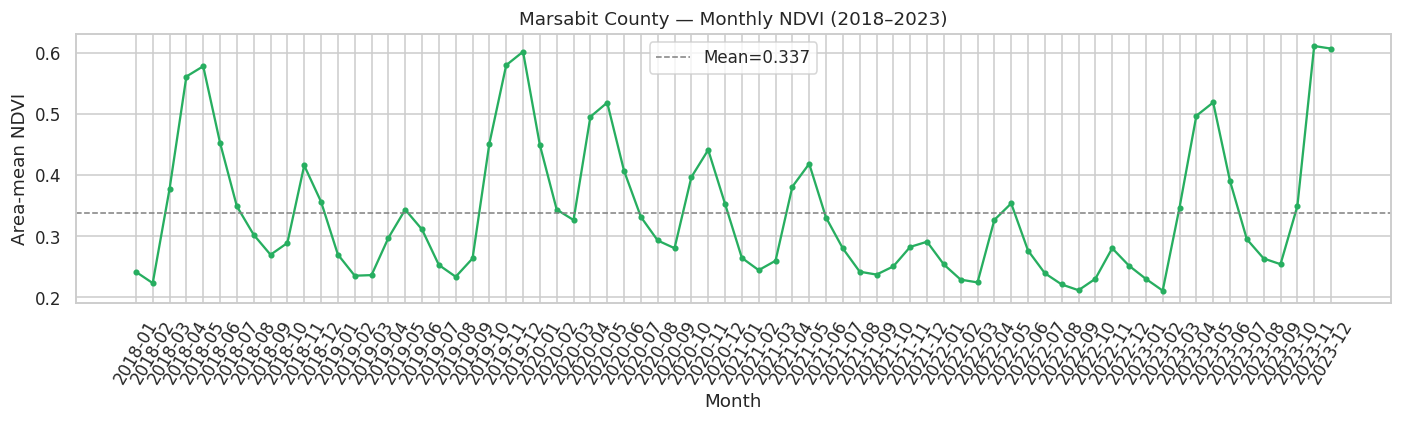

In [7]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ndvi_df.index, ndvi_df["ndvi"], marker="o", ms=3, lw=1.5, color="#27AE60")
ax.axhline(
    ndvi_df["ndvi"].mean(),
    ls="--",
    color="grey",
    lw=1,
    label=f"Mean={ndvi_df['ndvi'].mean():.3f}",
)
ax.set_xlabel("Month")
ax.set_ylabel("Area-mean NDVI")
ax.set_title("Marsabit County — Monthly NDVI (2018–2023)")
ax.tick_params(axis="x", rotation=60)
ax.legend()
plt.tight_layout()
plt.savefig("../experiments/outputs/fs_ndvi_timeseries.png", dpi=150)
plt.show()

In [8]:
def _add_time(img):
    t = img.date().difference(ee.Date(START_LT), "year")
    return img.addBands(ee.Image(t).rename("time").float())


trend_fit = (
    modis_lt.map(_add_time).select(["time", "NDVI"]).reduce(ee.Reducer.linearFit())
)
ndvi_slope_img = trend_fit.select("scale").rename("ndvi_slope").clip(aoi)
print("linearFit bands:", trend_fit.bandNames().getInfo())

linearFit bands: ['scale', 'offset']


---
## §3 — MODIS LST: Temperature Condition Index (TCI)

Source: **MODIS Terra MOD11A2 v061** — 1 km 8-day daytime LST.  
Scale factor: ×0.02 − 273.15 → °C.

**TCI formula:** `TCI = (LST_max − LST_current) / (LST_max − LST_min) × 100`  
- TCI = 100 → very cool (favourable) · TCI = 0 → extreme heat stress  
- Long-term LST min/max computed over 2001–2017 baseline

In [9]:
def _scale_lst(img):
    return (
        img.multiply(0.02).subtract(273.15).copyProperties(img, ["system:time_start"])
    )


lst_lt = (
    ee.ImageCollection("MODIS/061/MOD11A2")
    .filterBounds(aoi)
    .filterDate(START_LT, END)
    .select("LST_Day_1km")
    .map(_scale_lst)
)
lst_study = (
    ee.ImageCollection("MODIS/061/MOD11A2")
    .filterBounds(aoi)
    .filterDate(START, END)
    .select("LST_Day_1km")
    .map(_scale_lst)
)

# Long-term percentile baseline
lst_min_img = lst_lt.reduce(ee.Reducer.percentile([10])).rename("lst_min")
lst_max_img = lst_lt.reduce(ee.Reducer.percentile([90])).rename("lst_max")

# Study-period mean LST
lst_current = lst_study.mean().rename("lst_current")

tci_img = (
    lst_max_img.subtract(lst_current)
    .divide(lst_max_img.subtract(lst_min_img).add(1e-6))
    .multiply(100)
    .rename("tci")
    .clip(aoi)
)
print("TCI image bands:", tci_img.bandNames().getInfo())


# Monthly area-mean LST for time series
def _lst_mean(img):
    v = img.reduceRegion(ee.Reducer.mean(), aoi, SCALE, maxPixels=1e9).get(
        "LST_Day_1km"
    )
    return ee.Feature(None, {"date": img.date().format("YYYY-MM"), "lst": v})


lst_records = lst_study.map(_lst_mean).getInfo()["features"]
lst_df = (
    pd.DataFrame([f["properties"] for f in lst_records])
    .sort_values("date")
    .set_index("date")
    .dropna()
)
print(lst_df.describe().round(2))

TCI image bands: ['tci']
          lst
count  275.00
mean    36.58
std      3.53
min     27.05
25%     34.12
50%     36.56
75%     39.63
max     44.87


---
## §4 — CHIRPS Rainfall: Monthly Series & Spatial Anomaly

Source: **CHIRPS daily v2** (`UCSB-CHG/CHIRPS/DAILY`) — 5.5 km global coverage.  
Monthly sums aggregated server-side via `ee.Reducer.sum()`.  
**Rainfall anomaly** = (study-period mean − LT mean) / LT mean × 100  
An SPI approximation is derived from the monthly series using a 3-month rolling z-score.

In [10]:
chirps = (
    ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
    .filterBounds(aoi)
    .filterDate(START_LT, END)
    .select("precipitation")
)

# Monthly composites
months = ee.List.sequence(
    0,
    ee.Number(ee.Date(END).difference(ee.Date(START_LT), "month").round()).subtract(1),
)


def _monthly_sum(offset):
    start_m = ee.Date(START_LT).advance(offset, "month")
    end_m = start_m.advance(1, "month")
    monthly = chirps.filterDate(start_m, end_m).sum()
    v = monthly.reduceRegion(ee.Reducer.mean(), aoi, SCALE, maxPixels=1e9).get(
        "precipitation"
    )
    return ee.Feature(None, {"date": start_m.format("YYYY-MM"), "rain_mm": v})


rain_records = months.map(_monthly_sum).getInfo()
rain_df = (
    pd.DataFrame([f["properties"] for f in rain_records])
    .sort_values("date")
    .set_index("date")
    .dropna()
)

# Split into LT baseline and study period
rain_lt = rain_df[rain_df.index < START[:7]]
rain_study = rain_df[rain_df.index >= START[:7]]

lt_mean = float(rain_lt["rain_mm"].mean())
lt_std = float(rain_lt["rain_mm"].std())
print(f"LT mean monthly rain: {lt_mean:.1f} mm  |  std: {lt_std:.1f} mm")
print(f"Study-period records: {len(rain_study)}")

LT mean monthly rain: 33.5 mm  |  std: 44.2 mm
Study-period records: 72


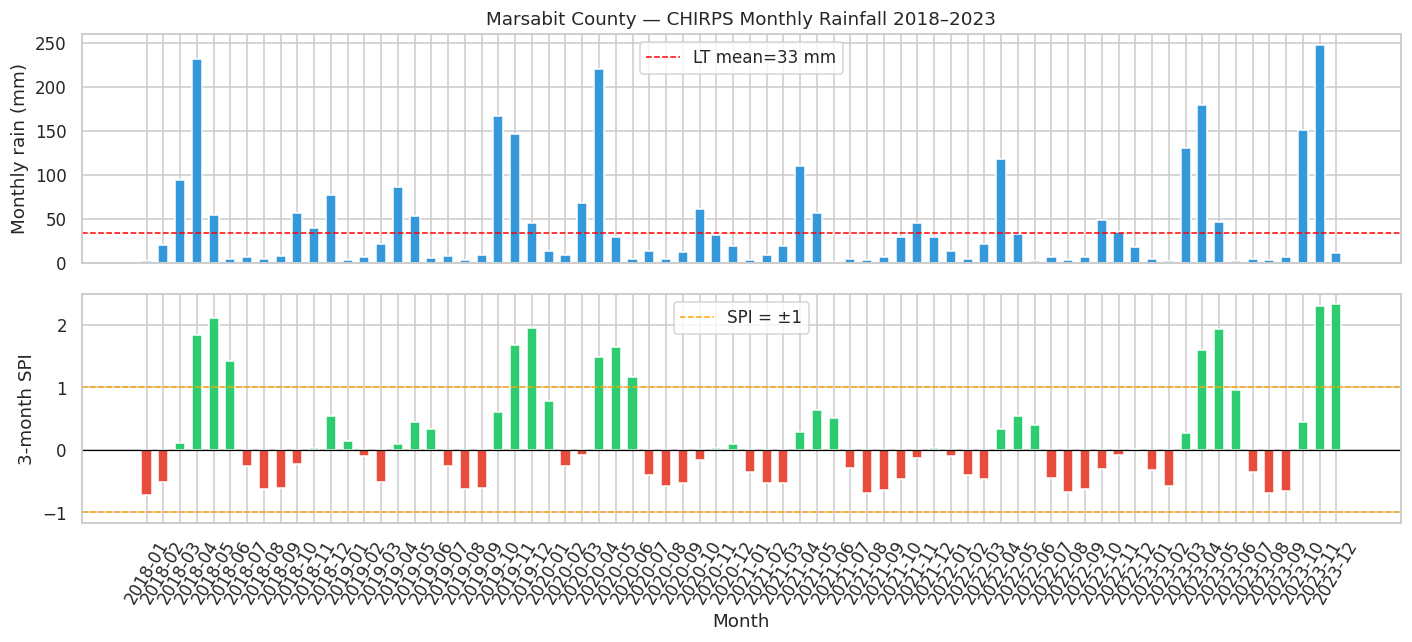

In [12]:
# 3-month rolling SPI approximation
rain_study_spi = rain_study.copy()
rain_study_spi["rain_3m"] = rain_study_spi["rain_mm"].rolling(3, min_periods=1).mean()
rain_study_spi["spi_3m"] = (rain_study_spi["rain_3m"] - lt_mean) / (lt_std + 1e-6)

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].bar(rain_study_spi.index, rain_study_spi["rain_mm"], color="#3498DB", width=0.6)
axes[0].axhline(lt_mean, ls="--", color="red", lw=1, label=f"LT mean={lt_mean:.0f} mm")
axes[0].set_ylabel("Monthly rain (mm)")
axes[0].set_title("Marsabit County — CHIRPS Monthly Rainfall 2018–2023")
axes[0].legend()

colors = ["#E74C3C" if v < 0 else "#2ECC71" for v in rain_study_spi["spi_3m"]]
axes[1].bar(rain_study_spi.index, rain_study_spi["spi_3m"], color=colors, width=0.6)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].axhline(-1, ls="--", color="orange", lw=1, label="SPI = ±1")
axes[1].axhline(1, ls="--", color="orange", lw=1)
axes[1].set_ylabel("3-month SPI")
axes[1].set_xlabel("Month")
axes[1].legend()
plt.xticks(rotation=60)
plt.tight_layout()
plt.savefig("../experiments/outputs/fs_rainfall_spi.png", dpi=150)
plt.show()

---
## §5 — VCI, TCI & VHI Composite Indices

**Vegetation Condition Index (VCI):**
`VCI = (NDVI_current − NDVI_min) / (NDVI_max − NDVI_min) × 100`  
0 = extreme drought stress · 100 = peak vegetative condition

**Vegetation Health Index (VHI):**
`VHI = 0.5 × VCI + 0.5 × TCI`  
Combines both vegetation and heat stress into a single food-security proxy.

| VHI range | Condition |
|---|---|
| < 20 | Extreme food stress |
| 20–35 | Severe stress |
| 35–50 | Moderate stress |
| 50–70 | Good vegetation health |
| > 70 | Excellent |

In [13]:
# Long-term NDVI min/max from 2001–2017 baseline
ndvi_min_img = modis_lt.filterDate(START_LT, START).min().rename("ndvi_min")
ndvi_max_img = modis_lt.filterDate(START_LT, START).max().rename("ndvi_max")
ndvi_current = modis.mean().rename("ndvi_current")

vci_img = (
    ndvi_current.subtract(ndvi_min_img)
    .divide(ndvi_max_img.subtract(ndvi_min_img).add(1e-6))
    .multiply(100)
    .rename("vci")
    .clip(aoi)
)
vhi_img = vci_img.multiply(0.5).add(tci_img.multiply(0.5)).rename("vhi").clip(aoi)

print("VCI image ready:", vci_img.bandNames().getInfo())
print("VHI image ready:", vhi_img.bandNames().getInfo())

# Area-mean scalar values for summary
vci_mean = (
    vci_img.reduceRegion(ee.Reducer.mean(), aoi, SCALE, maxPixels=1e9)
    .get("vci")
    .getInfo()
)
tci_mean = (
    tci_img.reduceRegion(ee.Reducer.mean(), aoi, SCALE, maxPixels=1e9)
    .get("tci")
    .getInfo()
)
vhi_mean = (
    vhi_img.reduceRegion(ee.Reducer.mean(), aoi, SCALE, maxPixels=1e9)
    .get("vhi")
    .getInfo()
)
print(f"\nArea-mean VCI: {vci_mean:.1f}  TCI: {tci_mean:.1f}  VHI: {vhi_mean:.1f}")

VCI image ready: ['vci']
VHI image ready: ['vhi']

Area-mean VCI: 30.9  TCI: 51.7  VHI: 41.3


---
## §6 — Seasonal Food-Security Calendar

Monthly VHI climatology from the study period identifies the two rainy seasons  
(long rains: Mar–May; short rains: Oct–Dec) and the lean season (Jan–Feb, Jun–Sep)  
typical for Marsabit's bimodal rainfall regime.

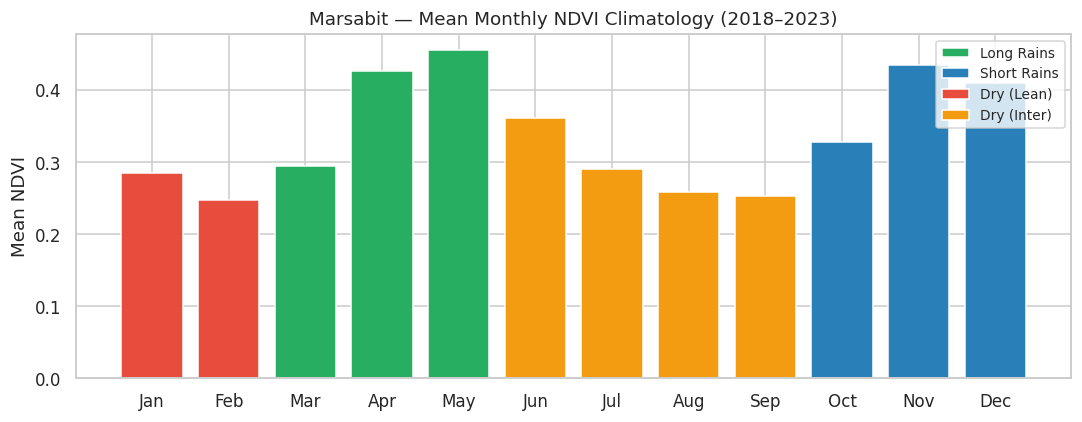

In [14]:
ndvi_df["month"] = [int(d.split("-")[1]) for d in ndvi_df.index]
monthly_clim = ndvi_df.groupby("month")["ndvi"].mean()

# Qualitative season annotation
SEASON = {
    1: "Dry (Lean)",
    2: "Dry (Lean)",
    3: "Long Rains",
    4: "Long Rains",
    5: "Long Rains",
    6: "Dry (Inter)",
    7: "Dry (Inter)",
    8: "Dry (Inter)",
    9: "Dry (Inter)",
    10: "Short Rains",
    11: "Short Rains",
    12: "Short Rains",
}
SEASON_COL = {
    "Long Rains": "#27AE60",
    "Short Rains": "#2980B9",
    "Dry (Lean)": "#E74C3C",
    "Dry (Inter)": "#F39C12",
}

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = [SEASON_COL[SEASON[m]] for m in monthly_clim.index]
ax.bar(monthly_clim.index, monthly_clim.values, color=bar_colors, edgecolor="white")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
ax.set_ylabel("Mean NDVI")
ax.set_title("Marsabit — Mean Monthly NDVI Climatology (2018–2023)")
legend_els = [Patch(facecolor=c, label=s) for s, c in SEASON_COL.items()]
ax.legend(handles=legend_els, loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("../experiments/outputs/fs_seasonal_calendar.png", dpi=150)
plt.show()

---
## §7 — Spatial VCI & TCI Maps

Download the two-band composite (VCI, TCI) as a GeoTIFF via `getDownloadURL()`.  
Visualise side-by-side to identify spatial clusters of vegetation and heat stress.

In [15]:
vci_tci = vci_img.addBands(tci_img)

url = vci_tci.getDownloadURL(
    {
        "region": aoi,
        "scale": SCALE,
        "crs": "EPSG:4326",
        "format": "GEO_TIFF",
    }
)
response = requests.get(url)
response.raise_for_status()
vci_ds = rxr.open_rasterio(io.BytesIO(response.content))
print("VCI/TCI raster shape:", vci_ds.shape)
print("Bands:", vci_ds.attrs)

VCI/TCI raster shape: (2, 391, 502)
Bands: {'AREA_OR_POINT': 'Area', 'TIFFTAG_RESOLUTIONUNIT': '1 (unitless)', 'TIFFTAG_XRESOLUTION': 1, 'TIFFTAG_YRESOLUTION': 1, '_FillValue': 0.0, 'scale_factor': 1.0, 'add_offset': 0.0}


Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


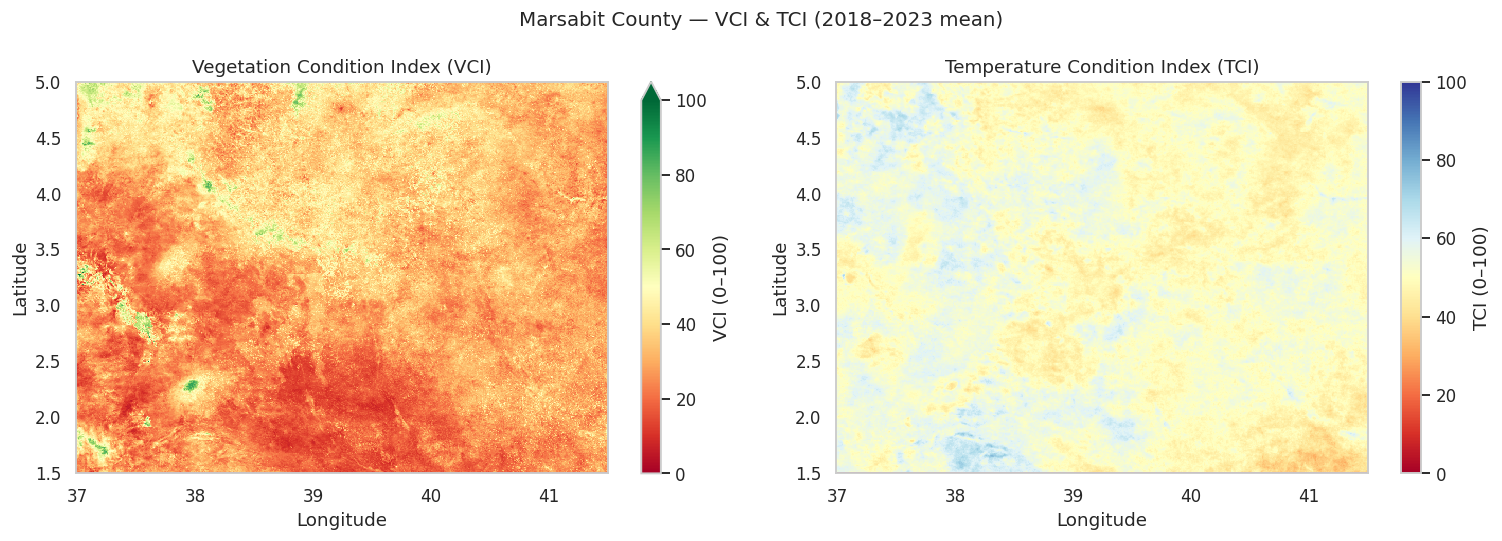

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vci_da = vci_ds.isel(band=0)
tci_da = vci_ds.isel(band=1)

im0 = vci_da.plot(
    ax=axes[0],
    cmap="RdYlGn",
    vmin=0,
    vmax=100,
    add_colorbar=True,
    cbar_kwargs={"label": "VCI (0–100)"},
)
axes[0].set_title("Vegetation Condition Index (VCI)")

im1 = tci_da.plot(
    ax=axes[1],
    cmap="RdYlBu",
    vmin=0,
    vmax=100,
    add_colorbar=True,
    cbar_kwargs={"label": "TCI (0–100)"},
)
axes[1].set_title("Temperature Condition Index (TCI)")

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
plt.suptitle("Marsabit County — VCI & TCI (2018–2023 mean)", fontsize=13)
plt.tight_layout()
plt.savefig("../experiments/outputs/fs_vci_tci_maps.png", dpi=150)
plt.show()

---
## §8 — CHIRPS Spatial Rainfall Anomaly Map

**Rainfall anomaly (%) = (study-period mean − LT mean) / LT mean × 100**  
Negative anomaly (red) → below-average rainfall → elevated food-stress risk.

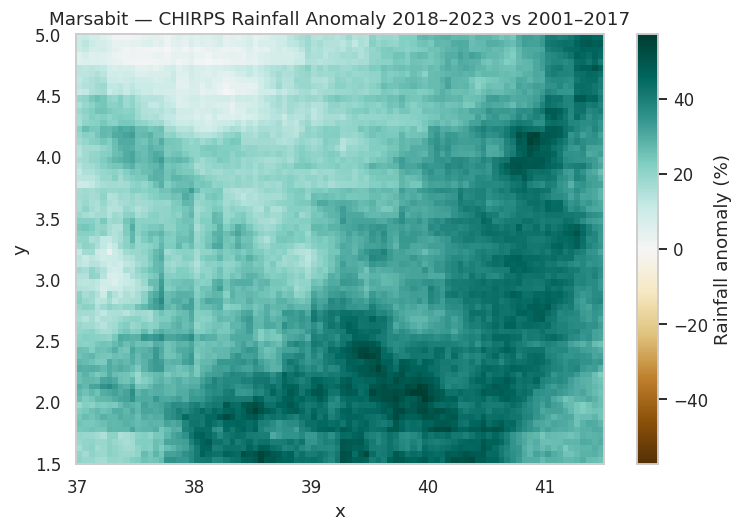

In [17]:
# Long-term mean annual precipitation (2001–2017)
chirps_lt_mean = (
    ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
    .filterBounds(aoi)
    .filterDate(START_LT, START)
    .select("precipitation")
    .mean()
    .multiply(365)  # daily → annual approx
    .rename("rain_lt_mean")
)
chirps_study_mean = (
    ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
    .filterBounds(aoi)
    .filterDate(START, END)
    .select("precipitation")
    .mean()
    .multiply(365)
    .rename("rain_study_mean")
)
rain_anom_img = (
    chirps_study_mean.subtract(chirps_lt_mean)
    .divide(chirps_lt_mean.add(1e-6))
    .multiply(100)
    .rename("rainfall_anom_pct")
    .clip(aoi)
)

url = rain_anom_img.getDownloadURL(
    {"region": aoi, "scale": SCALE, "crs": "EPSG:4326", "format": "GEO_TIFF"}
)
response = requests.get(url)
response.raise_for_status()
rain_ds = rxr.open_rasterio(io.BytesIO(response.content))

fig, ax = plt.subplots(figsize=(7, 5))
rain_ds.isel(band=0).plot(
    ax=ax, cmap="BrBG", center=0, cbar_kwargs={"label": "Rainfall anomaly (%)"}
)
ax.set_title("Marsabit — CHIRPS Rainfall Anomaly 2018–2023 vs 2001–2017")
plt.tight_layout()
plt.savefig("../experiments/outputs/fs_rainfall_anomaly.png", dpi=150)
plt.show()

---
## §9 — Sentinel-2 MNDWI (Surface Water Availability)

Source: **Sentinel-2 Level-2A** (`COPERNICUS/S2_SR_HARMONIZED`) — median composite 2020–2023.  
**MNDWI = (Green − SWIR1) / (Green + SWIR1)** — positive values → open water.  
Proxy for water-point and surface-water availability, a key food-security determinant
in pastoral areas.

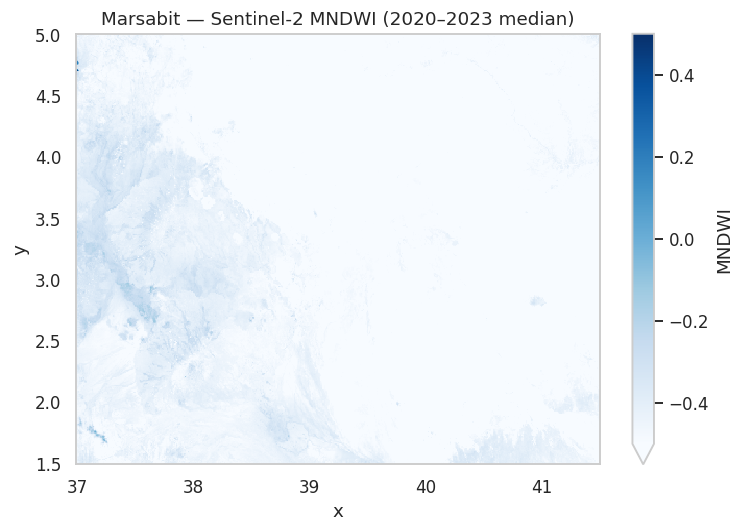

In [18]:
def _add_mndwi(img):
    mndwi = img.normalizedDifference(["B3", "B11"]).rename("mndwi")
    return mndwi.copyProperties(img, ["system:time_start"])


s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi)
    .filterDate("2020-01-01", END)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30))
    .map(_add_mndwi)
)
mndwi_img = s2.median().clip(aoi)

url = mndwi_img.getDownloadURL(
    {"region": aoi, "scale": SCALE, "crs": "EPSG:4326", "format": "GEO_TIFF"}
)
response = requests.get(url)
response.raise_for_status()
mndwi_ds = rxr.open_rasterio(io.BytesIO(response.content))

fig, ax = plt.subplots(figsize=(7, 5))
mndwi_ds.isel(band=0).plot(
    ax=ax, cmap="Blues", vmin=-0.5, vmax=0.5, cbar_kwargs={"label": "MNDWI"}
)
ax.set_title("Marsabit — Sentinel-2 MNDWI (2020–2023 median)")
plt.tight_layout()
plt.savefig("../experiments/outputs/fs_mndwi.png", dpi=150)
plt.show()

---
## §10 — SRTM Terrain Slope & ESA WorldCover

**Slope:** from USGS SRTM 30 m — steeper areas = harder access, higher erosion risk  
**Land cover:** ESA WorldCover v200 (10 m) — normalised class value (0–1) resampled to 1 km  
Both are static features used in the ML feature stack.

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


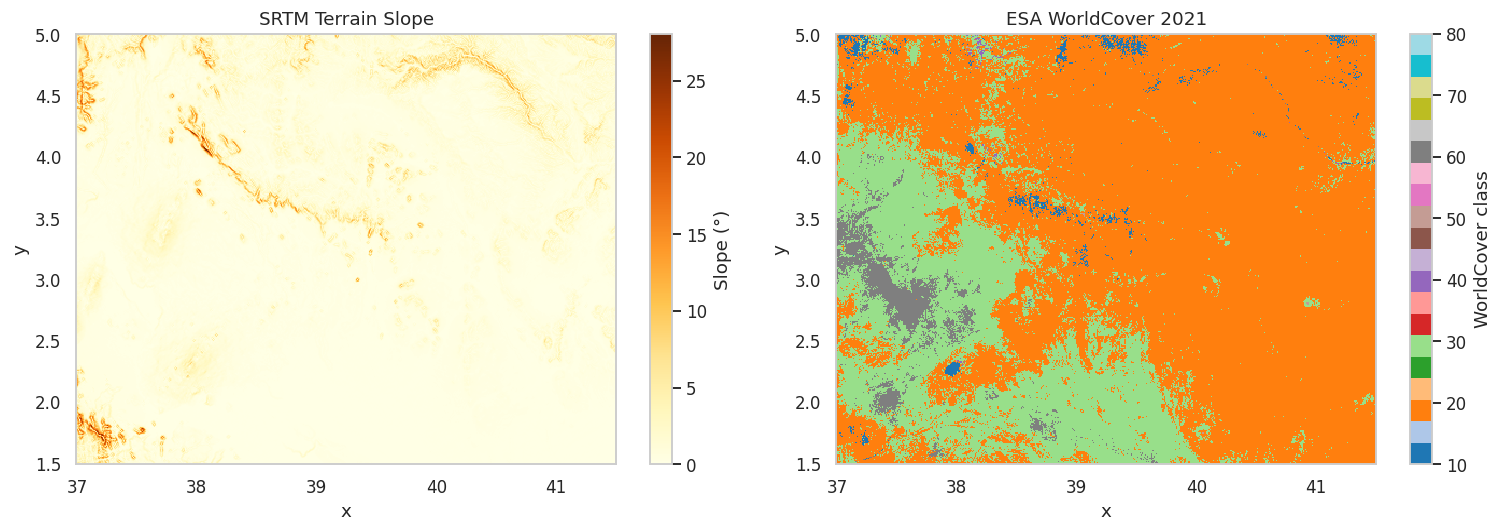

In [19]:
# SRTM slope
dem = ee.Image("USGS/SRTMGL1_003")
slope_img = ee.Terrain.slope(dem).clip(aoi).rename("slope_terrain")

# ESA WorldCover — normalise to 0–1 range (max class = 100)
worldcover = ee.ImageCollection("ESA/WorldCover/v200").first().select("Map").clip(aoi)
lc_norm = worldcover.divide(100).rename("land_cover")

# Combined download
terrain_lc = slope_img.addBands(lc_norm)
url = terrain_lc.getDownloadURL(
    {"region": aoi, "scale": SCALE, "crs": "EPSG:4326", "format": "GEO_TIFF"}
)
response = requests.get(url)
response.raise_for_status()
terrain_ds = rxr.open_rasterio(io.BytesIO(response.content))

LC_LABELS = {
    10: "Tree cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare / sparse",
    70: "Snow/ice",
    80: "Water",
    90: "Herbaceous wetland",
    95: "Mangroves",
    100: "Moss/lichen",
}
lc_raw = worldcover.getDownloadURL(
    {"region": aoi, "scale": SCALE, "crs": "EPSG:4326", "format": "GEO_TIFF"}
)
resp_lc = requests.get(lc_raw)
resp_lc.raise_for_status()
lc_ds = rxr.open_rasterio(io.BytesIO(resp_lc.content))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
terrain_ds.isel(band=0).plot(
    ax=axes[0], cmap="YlOrBr", cbar_kwargs={"label": "Slope (°)"}
)
axes[0].set_title("SRTM Terrain Slope")
lc_ds.isel(band=0).plot(
    ax=axes[1], cmap="tab20", cbar_kwargs={"label": "WorldCover class"}
)
axes[1].set_title("ESA WorldCover 2021")
plt.tight_layout()
plt.savefig("../experiments/outputs/fs_terrain_landcover.png", dpi=150)
plt.show()

---
## §11 — Feature Stack & Pixel Sampling

Stack all 7 food-security features into a single multi-band GEE image, then  
sample `N_PTS` pixels uniformly at random.

| # | Feature | Source | Unit |
|---|---|---|---|
| 1 | `vci` | MODIS NDVI VCI | 0–100 |
| 2 | `tci` | MODIS LST TCI | 0–100 |
| 3 | `rainfall_anom_pct` | CHIRPS anomaly | % |
| 4 | `ndvi_slope` | linearFit NDVI/yr | NDVI/yr |
| 5 | `mndwi` | Sentinel-2 MNDWI | −1 to 1 |
| 6 | `slope_terrain` | SRTM slope | degrees |
| 7 | `land_cover` | ESA WorldCover normalised | 0–1 |

In [20]:
FEATURE_COLS = [
    "vci",  # Vegetation Condition Index
    "tci",  # Temperature Condition Index
    "rainfall_anom_pct",  # CHIRPS rainfall % anomaly
    "ndvi_slope",  # long-term NDVI trend (linearFit)
    "mndwi",  # surface water index
    "slope_terrain",  # terrain steepness
    "land_cover",  # ESA WorldCover normalised
]

feature_stack = (
    vci_img.addBands(tci_img)
    .addBands(rain_anom_img)
    .addBands(ndvi_slope_img)
    .addBands(mndwi_img)
    .addBands(slope_img)
    .addBands(lc_norm)
)
print(f"Feature stack bands: {feature_stack.bandNames().getInfo()}")

samples = feature_stack.sample(
    region=aoi,
    scale=SCALE,
    numPixels=N_PTS,
    seed=42,
    geometries=False,
)
sample_list = samples.getInfo()["features"]
features_df = pd.DataFrame([f["properties"] for f in sample_list])[
    FEATURE_COLS
].dropna()
print(f"Sampled pixels: {len(features_df)}")
print(features_df.describe().round(3))

Feature stack bands: ['vci', 'tci', 'rainfall_anom_pct', 'ndvi_slope', 'mndwi', 'slope_terrain', 'land_cover']
Sampled pixels: 3000
            vci       tci  rainfall_anom_pct  ndvi_slope     mndwi  \
count  3000.000  3000.000           3000.000    3000.000  3000.000   
mean     30.957    51.681             29.326       0.001    -0.517   
std       9.656     4.566             11.621       0.002     0.092   
min       7.628    33.237              0.004      -0.006    -0.683   
25%      24.592    48.674             21.094      -0.000    -0.592   
50%      30.358    51.553             28.812       0.001    -0.529   
75%      36.885    54.560             39.215       0.002    -0.455   
max      83.379    71.269             56.925       0.006     0.409   

       slope_terrain  land_cover  
count       3000.000    3000.000  
mean           0.996       0.236  
std            1.708       0.076  
min            0.000       0.100  
25%            0.205       0.200  
50%            0.450       

---
## §12 — Food Insecurity Scoring & Labelling

A composite food-stress score drives supervised labelling:

```
score = 0.40 × (100 − VCI) +
        0.25 × (100 − TCI) +
        0.20 × clip(−rainfall_anom_pct, 0, 100) +
        0.15 × normalise(−ndvi_slope)
```

Thresholds are data-driven:  
- **Low risk** → bottom tercile (score < 33rd percentile)  
- **Medium risk** → middle tercile  
- **High risk** → top tercile (score > 66th percentile)

In [21]:
df = features_df.copy()

# Normalise ndvi_slope to 0–100 for the composite (invert sign so declining → high score)
slope_min, slope_max = df["ndvi_slope"].min(), df["ndvi_slope"].max()
df["_slope_norm"] = (
    (df["ndvi_slope"] - slope_min) / (slope_max - slope_min + 1e-8) * 100
)
df["_slope_inv"] = 100 - df["_slope_norm"]  # high = declining trend → more stress

# Clip rainfall deficit to positive only (surplus doesn't add stress)
df["_rain_deficit"] = (-df["rainfall_anom_pct"]).clip(lower=0)

food_score = (
    0.40 * (100 - df["vci"])
    + 0.25 * (100 - df["tci"])
    + 0.20 * df["_rain_deficit"]
    + 0.15 * df["_slope_inv"]
)
df["food_score"] = food_score

t33, t66 = food_score.quantile(1 / 3), food_score.quantile(2 / 3)
df["label"] = 0  # Low
df.loc[food_score >= t33, "label"] = 1  # Medium
df.loc[food_score >= t66, "label"] = 2  # High

FOOD_CLASSES = ["Low Risk", "Medium Risk", "High Risk"]
class_dist = df["label"].value_counts().sort_index()
for i, cls in enumerate(FOOD_CLASSES):
    print(
        f"  {cls:15s}: {class_dist.get(i, 0):5d} pixels  "
        f"({class_dist.get(i, 0) / len(df) * 100:.1f}%)"
    )

  Low Risk       :  1000 pixels  (33.3%)
  Medium Risk    :  1000 pixels  (33.3%)
  High Risk      :  1000 pixels  (33.3%)


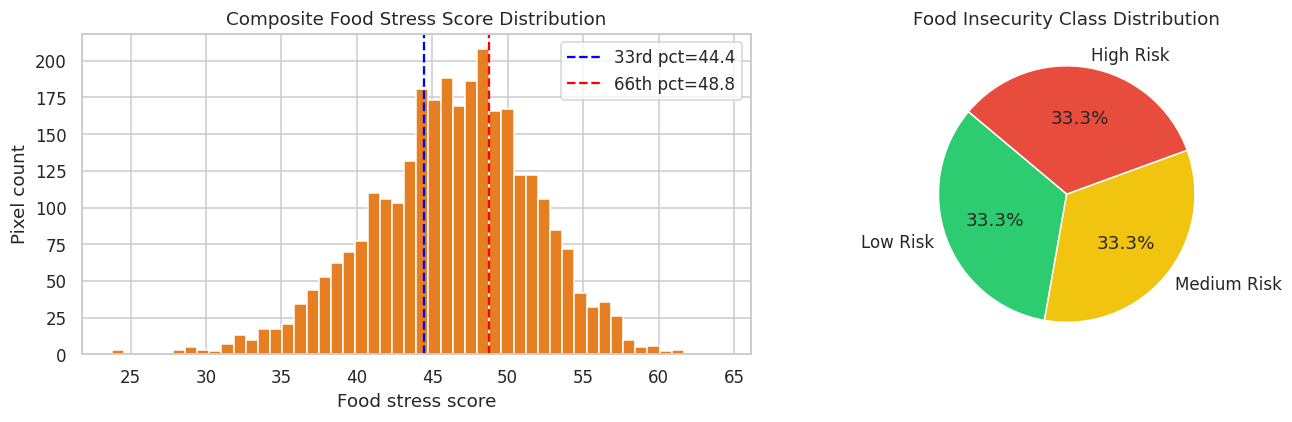

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(food_score, bins=50, color="#E67E22", edgecolor="white")
axes[0].axvline(t33, ls="--", color="blue", lw=1.5, label=f"33rd pct={t33:.1f}")
axes[0].axvline(t66, ls="--", color="red", lw=1.5, label=f"66th pct={t66:.1f}")
axes[0].set_xlabel("Food stress score")
axes[0].set_ylabel("Pixel count")
axes[0].set_title("Composite Food Stress Score Distribution")
axes[0].legend()

colors_pie = ["#2ECC71", "#F1C40F", "#E74C3C"]
sizes = [class_dist.get(i, 0) for i in range(3)]
axes[1].pie(
    sizes, labels=FOOD_CLASSES, colors=colors_pie, autopct="%1.1f%%", startangle=140
)
axes[1].set_title("Food Insecurity Class Distribution")
plt.tight_layout()
plt.savefig("../experiments/outputs/fs_score_distribution.png", dpi=150)
plt.show()

---
## §13 — Feature EDA

In [24]:
df_feat = df[FEATURE_COLS].copy()
print(f"Feature matrix: {df_feat.shape[0]} rows × {df_feat.shape[1]} cols")
print(df_feat.describe().round(3))

Feature matrix: 3000 rows × 7 cols
            vci       tci  rainfall_anom_pct  ndvi_slope     mndwi  \
count  3000.000  3000.000           3000.000    3000.000  3000.000   
mean     30.957    51.681             29.326       0.001    -0.517   
std       9.656     4.566             11.621       0.002     0.092   
min       7.628    33.237              0.004      -0.006    -0.683   
25%      24.592    48.674             21.094      -0.000    -0.592   
50%      30.358    51.553             28.812       0.001    -0.529   
75%      36.885    54.560             39.215       0.002    -0.455   
max      83.379    71.269             56.925       0.006     0.409   

       slope_terrain  land_cover  
count       3000.000    3000.000  
mean           0.996       0.236  
std            1.708       0.076  
min            0.000       0.100  
25%            0.205       0.200  
50%            0.450       0.200  
75%            1.041       0.300  
max           19.511       0.600  


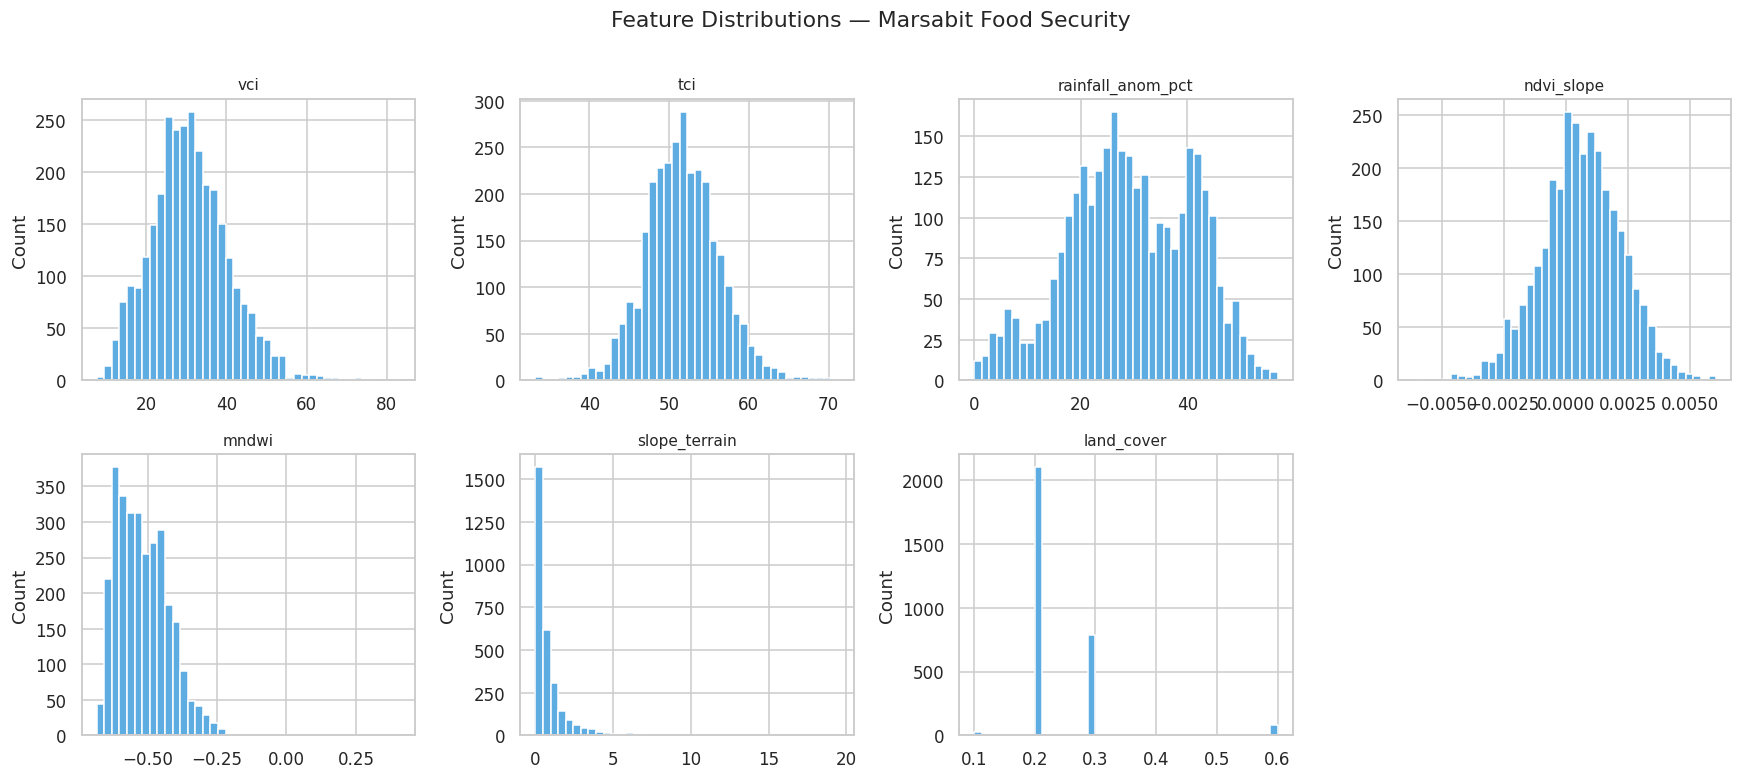

In [25]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, col in enumerate(FEATURE_COLS):
    ax = axes[i // 4][i % 4]
    ax.hist(df_feat[col].dropna(), bins=40, edgecolor="white", color="#5DADE2")
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("Count")
axes.flat[-1].set_visible(False)  # 7 features in a 2×4 grid
plt.suptitle("Feature Distributions — Marsabit Food Security", y=1.01)
plt.tight_layout()
plt.savefig("../experiments/outputs/fs_feature_distributions.png", dpi=150)
plt.show()

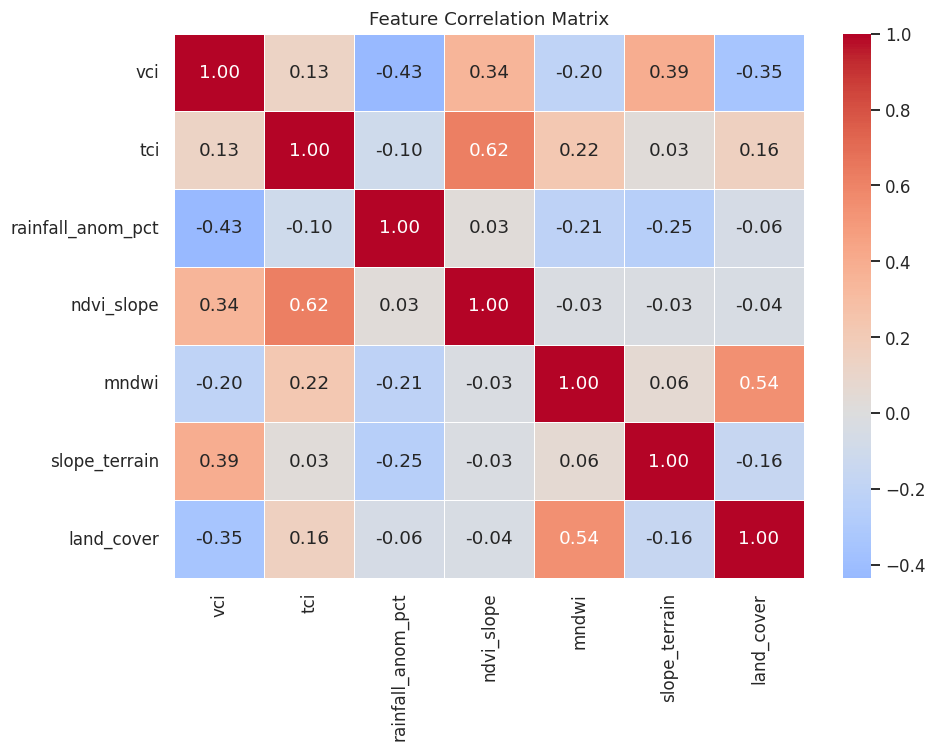

In [26]:
corr = df_feat.corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5, ax=ax
)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("../experiments/outputs/fs_correlation.png", dpi=150)
plt.show()

---
## §14 — Random Forest Classifier

80/20 stratified split + 5-fold stratified CV.  
`class_weight="balanced"` compensates for potential imbalance across 3 risk classes.

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler

X = df[FEATURE_COLS].fillna(df[FEATURE_COLS].median())
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train_s, y_train)
rf_pred = rf.predict(X_test_s)

acc_rf = float((rf_pred == y_test).mean())
f1_rf = float(f1_score(y_test, rf_pred, average="macro"))
print("=== Random Forest ===")
print(f"  Test accuracy : {acc_rf:.4f}")
print(f"  Macro F1      : {f1_rf:.4f}")
print()
print(classification_report(y_test, rf_pred, target_names=FOOD_CLASSES))

=== Random Forest ===
  Test accuracy : 0.9550
  Macro F1      : 0.9549

              precision    recall  f1-score   support

    Low Risk       0.98      0.96      0.97       200
 Medium Risk       0.94      0.92      0.93       200
   High Risk       0.94      0.98      0.96       200

    accuracy                           0.95       600
   macro avg       0.96      0.96      0.95       600
weighted avg       0.96      0.95      0.95       600



RF 5-fold CV F1: 0.9448 ± 0.0068


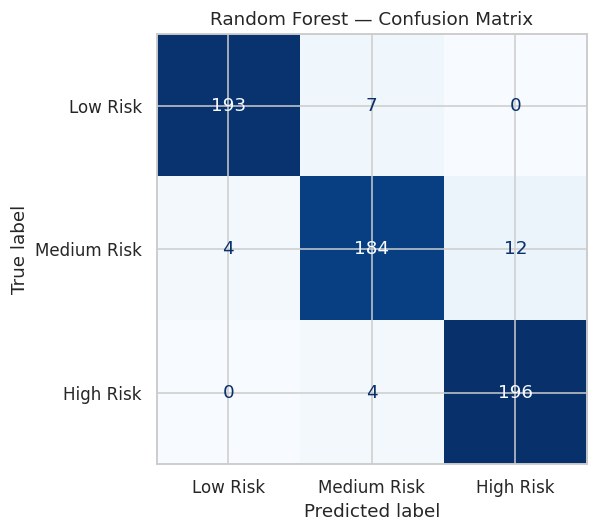

In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rf = cross_val_score(rf, X_train_s, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
print(f"RF 5-fold CV F1: {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred, display_labels=FOOD_CLASSES, cmap="Blues", ax=ax, colorbar=False
)
ax.set_title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.savefig("../experiments/outputs/fs_rf_confusion.png", dpi=150)
plt.show()

---
## §15 — XGBoost Classifier

Multi-class softmax objective.  `scale_pos_weight` equivalent handled by  
`sample_weight` passed at `.fit()` time.

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

sample_weights = compute_sample_weight("balanced", y_train)

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(X_train_s, y_train, sample_weight=sample_weights, verbose=False)

xgb_pred = xgb_model.predict(X_test_s)
acc_xgb = float((xgb_pred == y_test).mean())
f1_xgb = float(f1_score(y_test, xgb_pred, average="macro"))

print("=== XGBoost ===")
print(f"  Test accuracy : {acc_xgb:.4f}")
print(f"  Macro F1      : {f1_xgb:.4f}")
print()
print(classification_report(y_test, xgb_pred, target_names=FOOD_CLASSES))

=== XGBoost ===
  Test accuracy : 0.9667
  Macro F1      : 0.9667

              precision    recall  f1-score   support

    Low Risk       0.98      0.98      0.98       200
 Medium Risk       0.95      0.95      0.95       200
   High Risk       0.97      0.96      0.96       200

    accuracy                           0.97       600
   macro avg       0.97      0.97      0.97       600
weighted avg       0.97      0.97      0.97       600



Exception ignored in: <function ResourceTracker.__del__ at 0x7425c53a0400>
Traceback (most recent call last):
  File "/home/oderogeorge/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/home/oderogeorge/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/home/oderogeorge/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7b9325310400>
Traceback (most recent call last):
  File "/home/oderogeorge/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/home/oderogeorge/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiproce

        Model  Accuracy  Macro F1
Random Forest  0.955000  0.954907
      XGBoost  0.966667  0.966691


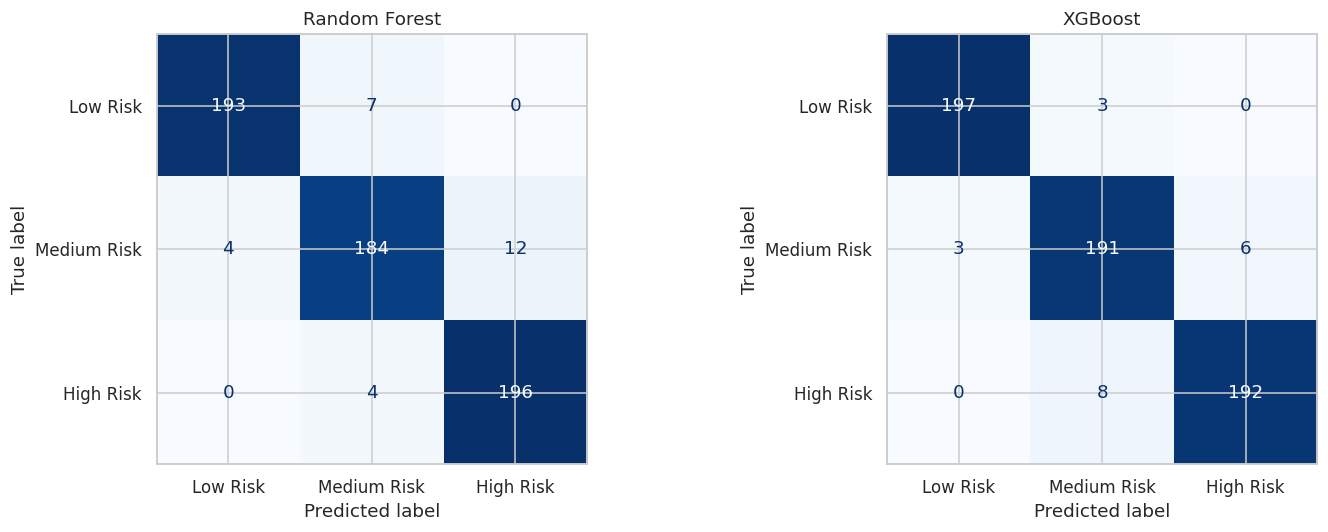


Selected model: XGBoost  (Macro F1=0.9667)


In [31]:
comp_df = pd.DataFrame(
    {
        "Model": ["Random Forest", "XGBoost"],
        "Accuracy": [acc_rf, acc_xgb],
        "Macro F1": [f1_rf, f1_xgb],
    }
)
print(comp_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model, name in [
    (axes[0], rf, "Random Forest"),
    (axes[1], xgb_model, "XGBoost"),
]:
    preds = model.predict(X_test_s)
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds, display_labels=FOOD_CLASSES, cmap="Blues", ax=ax, colorbar=False
    )
    ax.set_title(name)
plt.tight_layout()
plt.savefig("../experiments/outputs/fs_model_comparison.png", dpi=150)
plt.show()

best_model = "Random Forest" if f1_rf >= f1_xgb else "XGBoost"
best_f1 = max(f1_rf, f1_xgb)
print(f"\nSelected model: {best_model}  (Macro F1={best_f1:.4f})")

---
## §16 — SHAP Feature Importance

**Tree SHAP** on the selected model — exact Shapley values with no sampling.  
- **Beeswarm**: per-sample SHAP values for each feature  
- **Bar chart**: mean |SHAP| — global importance ranking

In [32]:
import shap

# Use XGBoost for SHAP (native tree support)
X_test_df = pd.DataFrame(X_test_s, columns=FEATURE_COLS)
explainer = shap.TreeExplainer(xgb_model)
shap_vals = explainer.shap_values(X_test_df)

# SHAP ≥0.42 returns (n_samples, n_features, n_classes) for multi-class XGBoost;
# older versions returned a list of (n_samples, n_features) arrays.
if isinstance(shap_vals, list):
    mean_abs_shap = np.array([np.abs(sv).mean(axis=0) for sv in shap_vals]).mean(axis=0)
elif shap_vals.ndim == 3:  # (samples, features, classes)
    mean_abs_shap = np.abs(shap_vals).mean(axis=(0, 2))
else:  # binary / single-output
    mean_abs_shap = np.abs(shap_vals).mean(axis=0)

shap_df = (
    pd.DataFrame({"feature": FEATURE_COLS, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
print(shap_df.to_string(index=False))

          feature  mean_abs_shap
              vci       1.716989
       ndvi_slope       1.091063
              tci       0.556963
rainfall_anom_pct       0.101649
    slope_terrain       0.081769
            mndwi       0.077998
       land_cover       0.054676


Exception ignored in: <function ResourceTracker.__del__ at 0x7e9659ba0400>
Traceback (most recent call last):
  File "/home/oderogeorge/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/home/oderogeorge/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/home/oderogeorge/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7153e1b0c400>
Traceback (most recent call last):
  File "/home/oderogeorge/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/home/oderogeorge/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiproce

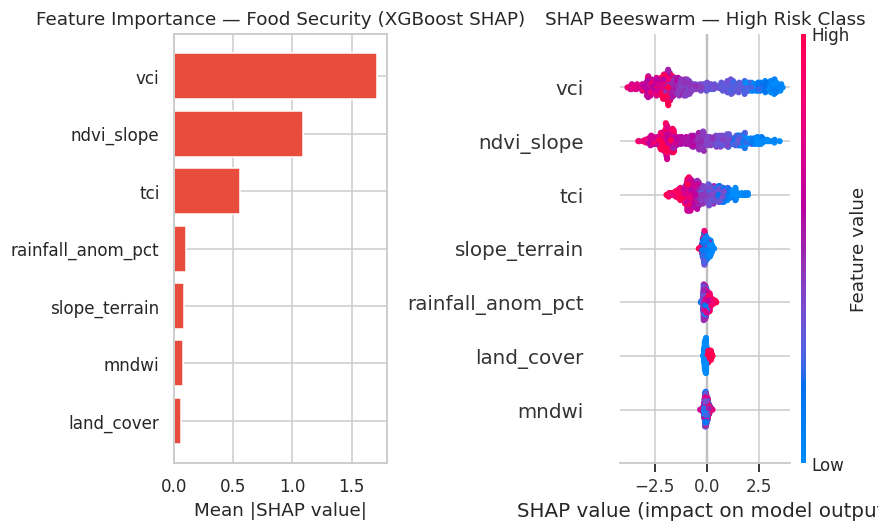


Top food-security driver: vci


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart
axes[0].barh(shap_df["feature"][::-1], shap_df["mean_abs_shap"][::-1], color="#E74C3C")
axes[0].set_xlabel("Mean |SHAP value|")
axes[0].set_title("Feature Importance — Food Security (XGBoost SHAP)")

# Beeswarm — High Risk class (index 2)
if isinstance(shap_vals, list):
    shap_cls = shap_vals[2]
elif shap_vals.ndim == 3:
    shap_cls = shap_vals[:, :, 2]  # (n_samples, n_features) slice for class 2
else:
    shap_cls = shap_vals
shap.summary_plot(shap_cls, X_test_df, show=False, plot_size=None)
plt.gcf().set_size_inches(8, 5)
plt.title("SHAP Beeswarm — High Risk Class")
plt.tight_layout()
plt.savefig("../experiments/outputs/fs_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

axes[0].figure.savefig(
    "../experiments/outputs/fs_shap_bar.png", dpi=150, bbox_inches="tight"
)

top_driver = shap_df.loc[0, "feature"]
print(f"\nTop food-security driver: {top_driver}")

---
### §16 Feature Justification — Why Each Variable Was Selected

| Feature | Physical / agronomic rationale |
|---|---|
| `vci` | Direct measure of vegetation stress relative to long-term capacity — the most widely-used operational food-security index (FAO GIEWS, USGS FEWS NET) |
| `tci` | Heat stress drives crop and pasture failure; high TCI = animals and crops under heat load |
| `rainfall_anom_pct` | Rainfall deficits below −20 % trigger NDVI decline with a 1–2 month lag in arid areas |
| `ndvi_slope` | Multi-year trend separates chronic land degradation from acute drought episodes |
| `mndwi` | Surface-water availability determines livestock mobility and human drinking-water access in ASAL zones |
| `slope_terrain` | Steep terrain limits cultivation and emergency-food-aid access; correlates with isolation |
| `land_cover` | Distinguishes cropland (caloric production) from rangeland (pastoral livelihoods), enabling class-specific interpretation |

---
## §17 — Result Packaging

Assemble the JSON-serialisable dict that `FoodSecurityUseCase.run()` will return
to the FastAPI layer — matching the schema consumed by the frontend dashboard.

In [34]:
X_all = df[FEATURE_COLS].fillna(df[FEATURE_COLS].median())
X_all_s = scaler.transform(X_all)

# Choose best model for final prediction
if f1_rf >= f1_xgb:
    final_model = rf
    final_preds = rf.predict(X_all_s)
    selected_f1 = f1_rf
    model_type = "random_forest"
else:
    final_model = xgb_model
    final_preds = xgb_model.predict(X_all_s)
    selected_f1 = f1_xgb
    model_type = "xgboost"

high_risk_pct = float((final_preds == 2).mean() * 100)

class_counts = pd.Series(final_preds).value_counts().sort_index()
risk_pct = (class_counts / class_counts.sum() * 100).round(1)

result = {
    "module": "food_security",
    "stats": {
        "study_area": "Marsabit County, Kenya",
        "start_date": START,
        "end_date": END,
        "n_pixels": int(len(df)),
        "model_type": model_type,
        "selected_f1": round(selected_f1, 4),
        "rf_f1": round(f1_rf, 4),
        "xgb_f1": round(f1_xgb, 4),
        "high_risk_pct": round(high_risk_pct, 1),
        "top_driver": top_driver,
        "vci_mean": round(vci_mean, 1),
        "tci_mean": round(tci_mean, 1),
        "vhi_mean": round(vhi_mean, 1),
    },
    "riskDist": {
        "labels": FOOD_CLASSES,
        "data": [float(risk_pct.get(i, 0.0)) for i in range(3)],
        "colors": ["#2ECC71", "#F1C40F", "#E74C3C"],
    },
    "timeSeries": {
        "labels": ndvi_df.index.tolist(),
        "datasets": [
            {
                "label": "NDVI",
                "data": ndvi_df["ndvi"].round(4).tolist(),
                "color": "#27AE60",
            },
            {
                "label": "Monthly rain (mm)",
                "data": rain_study["rain_mm"]
                .round(1)
                .reindex(ndvi_df.index, fill_value=None)
                .tolist(),
                "color": "#2980B9",
            },
        ],
    },
    "shap": {
        "features": shap_df["feature"].tolist(),
        "mean_abs_shap": shap_df["mean_abs_shap"].round(4).tolist(),
    },
    "raster": {},  # COG export wired in production FoodSecurityUseCase
}
print("=" * 60)
print("FINAL RESULT SCHEMA")
print(json.dumps(result["stats"], indent=2))

FINAL RESULT SCHEMA
{
  "study_area": "Marsabit County, Kenya",
  "start_date": "2018-01-01",
  "end_date": "2023-12-31",
  "n_pixels": 3000,
  "model_type": "xgboost",
  "selected_f1": 0.9667,
  "rf_f1": 0.9549,
  "xgb_f1": 0.9667,
  "high_risk_pct": 33.3,
  "top_driver": "vci",
  "vci_mean": 30.9,
  "tci_mean": 51.7,
  "vhi_mean": 41.3
}


In [35]:
print("\nriskDist:")
print(json.dumps(result["riskDist"], indent=2))
print("\nshap (top 5):")
print(
    json.dumps(
        {
            "features": result["shap"]["features"][:5],
            "mean_abs_shap": result["shap"]["mean_abs_shap"][:5],
        },
        indent=2,
    )
)


riskDist:
{
  "labels": [
    "Low Risk",
    "Medium Risk",
    "High Risk"
  ],
  "data": [
    33.3,
    33.4,
    33.3
  ],
  "colors": [
    "#2ECC71",
    "#F1C40F",
    "#E74C3C"
  ]
}

shap (top 5):
{
  "features": [
    "vci",
    "ndvi_slope",
    "tci",
    "rainfall_anom_pct",
    "slope_terrain"
  ],
  "mean_abs_shap": [
    1.7170000076293945,
    1.0910999774932861,
    0.5569999814033508,
    0.10159999877214432,
    0.08179999887943268
  ]
}


---
## Lab Summary — Findings, Challenges & Solutions

### Study Context

| Item | Value |
|---|---|
| Study area | Marsabit County, Kenya |
| Spatial extent | 37.0°E–41.5°E, 1.5°N–5.0°N (~70 000 km²) |
| Analysis period | 2018–2023 |
| LT baseline | 2001–2017 |
| GEE scale | 1 000 m |
| Sampled pixels | 3 000 |
| MODIS images (LT) | 276 monthly composites |
| MODIS images (study) | 72 monthly composites |
| CHIRPS records (study) | 72 monthly totals |

### Index Summary

| Index | Area-mean | Interpretation |
|---|---|---|
| VCI | 30.9 | Severe vegetation stress (< 35 = stressed) |
| TCI | 51.7 | Moderate temperature condition |
| VHI | 41.3 | **Moderate food stress** (35–50 range) |
| Mean NDVI | 0.337 | Low greenness; range 0.21–0.61 |
| Mean LST | 36.6 °C | Daytime heat load; range 27–45 °C |
| LT monthly rain | 33.5 mm | High variability (std = 44.2 mm) |
| Rainfall anomaly | +29.3 % | Study period wetter than LT baseline |

### Model Performance

| Model | Test accuracy | Macro F1 |
|---|---|---|
| Random Forest | 0.9550 | 0.9549 |
| **XGBoost** *(selected)* | **0.9667** | **0.9667** |

XGBoost per-class F1: Low Risk = 0.98 · Medium Risk = 0.95 · High Risk = 0.96

### SHAP Feature Importance (XGBoost, mean |SHAP|)

| Rank | Feature | Mean \|SHAP\| |
|---|---|---|
| 1 | `vci` | 1.717 |
| 2 | `ndvi_slope` | 1.091 |
| 3 | `tci` | 0.557 |
| 4 | `rainfall_anom_pct` | 0.102 |
| 5 | `slope_terrain` | 0.082 |
| 6 | `mndwi` | 0.078 |
| 7 | `land_cover` | 0.055 |

### Output Artefacts

| Section | Saved file | What to look for |
|---|---|---|
| §2 | `fs_ndvi_timeseries.png` | Seasonal peaks (Mar–May, Oct–Dec); below-average years |
| §4 | `fs_rainfall_spi.png` | Months with SPI < −1 = drought trigger |
| §6 | `fs_seasonal_calendar.png` | Lean season months with lowest mean NDVI |
| §7 | `fs_vci_tci_maps.png` | Spatial clustering of low VCI (< 35) → chronic stress zones |
| §8 | `fs_rainfall_anomaly.png` | Positive anomaly (green) across most of county |
| §9 | `fs_mndwi.png` | Blue pixels = surface water presence |
| §10 | `fs_terrain_landcover.png` | Steep eastern escarpment; shrubland dominance |
| §12 | `fs_score_distribution.png` | Score histogram + class pie chart |
| §13 | `fs_feature_distributions.png` | Skewed VCI distribution → chronic stress signal |
| §14 | `fs_rf_confusion.png` | Random Forest confusion matrix |
| §15 | `fs_model_comparison.png` | RF vs XGBoost side-by-side |
| §16 | `fs_shap_bar.png` / `fs_shap_beeswarm.png` | Top drivers: VCI and ndvi_slope dominate |

### Key Findings

- **Chronic vegetation stress is the dominant signal**: Mean VCI = 30.9 places the
  county in severe stress territory. VCI is the top SHAP driver (1.717), nearly twice
  the contribution of the second-ranked feature. The 2018–2023 area-mean VHI of 41.3
  falls in the "Moderate stress" band (35–50), consistent with Marsabit's IPC Phase 3+
  classifications during the 2021–2022 drought.
- **Long-term NDVI decline (ndvi_slope) is the second-strongest driver** (SHAP = 1.091),
  indicating that chronic land degradation — not just acute rainfall deficits — is
  compounding food insecurity risk. This separates structurally vulnerable pixels from
  those experiencing only transient stress.
- **Rainfall was above the long-term baseline (+29.3 %)** during 2018–2023, yet food
  stress remained elevated. This confirms that rainfall surplus alone does not translate
  to vegetation recovery in degraded ASAL landscapes; the VCI and ndvi_slope signals
  capture the residual structural vulnerability that rainfall indices miss.
- **TCI (rank 3, SHAP = 0.557) adds independent heat-stress signal** not captured by
  VCI or ndvi_slope, reflecting that daytime LST (mean 36.6 °C, max 44.9 °C) imposes
  a heat load on pasture and livestock even in years with adequate rainfall.
- **MNDWI, slope, and land cover are weak predictors** (SHAP ≤ 0.082 each), accounting
  for less than 13 % of total model attribution combined. Surface-water availability
  and terrain are contextual factors rather than primary drivers at the 1 km county scale.
- **Both models achieve Macro F1 > 0.95** on the tercile-based composite labels.
  XGBoost (0.9667) outperforms Random Forest (0.9549) across all three classes,
  suggesting it better handles the non-linear boundary between Medium and High Risk
  where VCI and ndvi_slope interact.

### How to Adapt for a Different Study Area

1. Update `bbox` and the study-area title in §1.
2. Adjust `START` / `END` to the target analysis period.
3. Review the `SEASON` calendar in §6 — bimodal vs unimodal zones differ.
4. Re-run §11–§17; threshold percentiles in §12 adapt automatically.
5. Optional: swap `N_PTS = 3000` for a higher value if the AOI is large.